# Actividad 15 – Segmentación por color

**Objetivo**: usar espacio de color HSV para segmentar objetos por color.

En esta actividad vamos a:
1. Cargar una imagen
2. Convertir de BGR a HSV
3. Crear una máscara para un color específico (verde)
4. Aplicar bitwise_and para extraer el objeto
5. Mostrar solo el objeto del color elegido

## 1. Importar librerías necesarias

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Configurar matplotlib para mostrar imágenes en el notebook
%matplotlib inline

## 2. Cargar imagen

✓ Imagen cargada correctamente
  Dimensiones: (333, 500, 3)


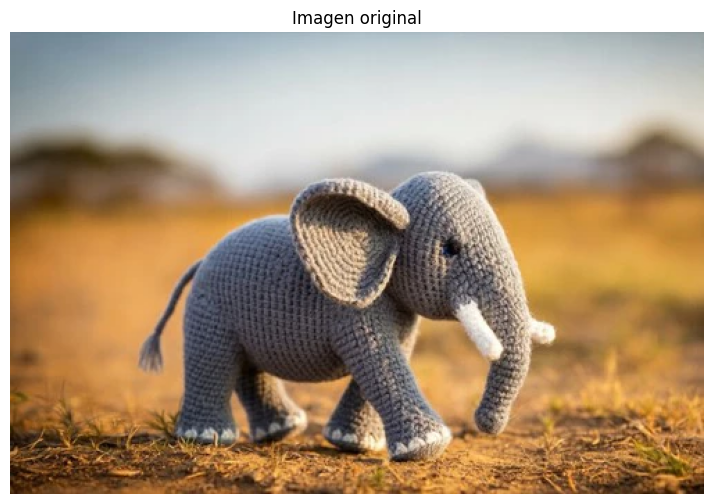

In [2]:
# Cargar la imagen
imagen = cv2.imread('imagen.webp')

# Verificar que la imagen se cargó correctamente
if imagen is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta del archivo.")
else:
    print("✓ Imagen cargada correctamente")
    print(f"  Dimensiones: {imagen.shape}")
    
    # Convertir BGR a RGB para visualización
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(imagen_rgb)
    plt.title('Imagen original')
    plt.axis('off')
    plt.show()

## 3. Convertir imagen a HSV

HSV (Hue, Saturation, Value) es mejor que BGR para segmentación por color porque separa el color (Hue) de la luminosidad (Value).

✓ Imagen convertida a HSV
  Dimensiones: (333, 500, 3)
  Canales: H (Hue/Matiz), S (Saturation/Saturación), V (Value/Valor)

  Rangos en OpenCV:
  • H: 0-179 (ángulo de color / 2)
  • S: 0-255 (intensidad del color)
  • V: 0-255 (brillo)


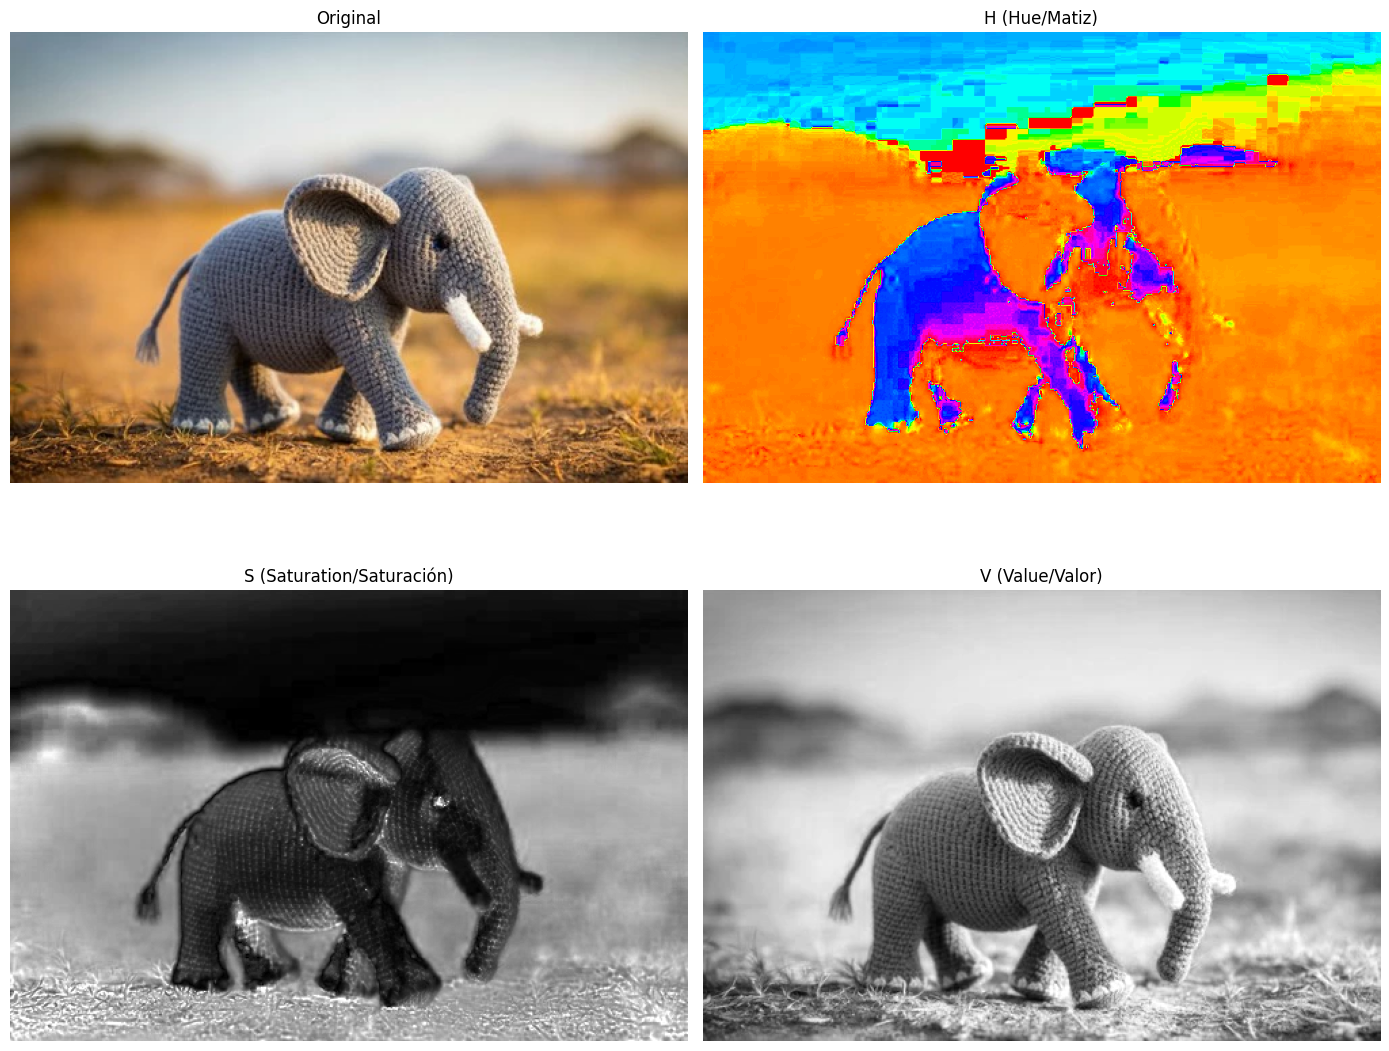

In [3]:
# Convertir de BGR a HSV
imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

print("✓ Imagen convertida a HSV")
print(f"  Dimensiones: {imagen_hsv.shape}")
print(f"  Canales: H (Hue/Matiz), S (Saturation/Saturación), V (Value/Valor)")
print(f"\n  Rangos en OpenCV:")
print(f"  • H: 0-179 (ángulo de color / 2)")
print(f"  • S: 0-255 (intensidad del color)")
print(f"  • V: 0-255 (brillo)")

# Separar canales HSV para visualización
h, s, v = cv2.split(imagen_hsv)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(imagen_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(h, cmap='hsv')
axes[0, 1].set_title('H (Hue/Matiz)')
axes[0, 1].axis('off')

axes[1, 0].imshow(s, cmap='gray')
axes[1, 0].set_title('S (Saturation/Saturación)')
axes[1, 0].axis('off')

axes[1, 1].imshow(v, cmap='gray')
axes[1, 1].set_title('V (Value/Valor)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Crear máscara para un color específico (verde)

Definimos un rango de valores HSV para detectar el color verde.

✓ Máscara de color verde creada
  Rango H (Hue): 35-85
  Rango S (Saturation): 50-255
  Rango V (Value): 50-255

  Píxeles detectados (blancos): 4
  Píxeles no detectados (negros): 166496


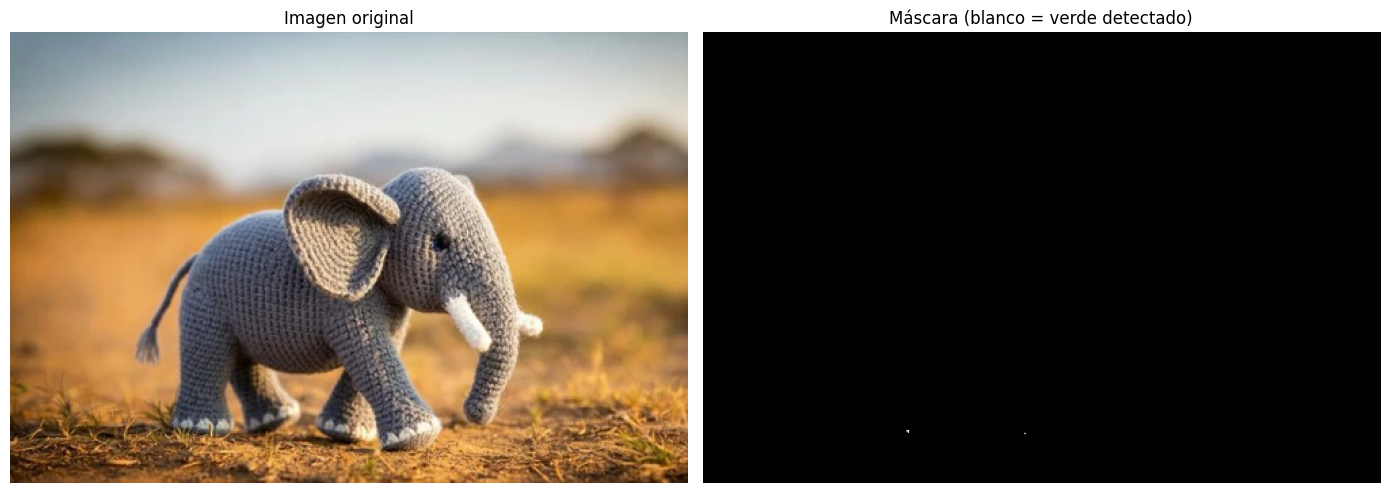

In [4]:
# Definir rango de color verde en HSV
# Verde está aproximadamente entre H=40-80 en OpenCV (H va de 0-179)
# Ajustar estos valores según la tonalidad específica de verde en la imagen

# Límite inferior (verde oscuro)
lower_green = np.array([35, 50, 50])

# Límite superior (verde claro)
upper_green = np.array([85, 255, 255])

# Crear máscara: píxeles dentro del rango = 255 (blanco), fuera = 0 (negro)
mask = cv2.inRange(imagen_hsv, lower_green, upper_green)

print("✓ Máscara de color verde creada")
print(f"  Rango H (Hue): {lower_green[0]}-{upper_green[0]}")
print(f"  Rango S (Saturation): {lower_green[1]}-{upper_green[1]}")
print(f"  Rango V (Value): {lower_green[2]}-{upper_green[2]}")
print(f"\n  Píxeles detectados (blancos): {np.sum(mask == 255)}")
print(f"  Píxeles no detectados (negros): {np.sum(mask == 0)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Máscara (blanco = verde detectado)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Aplicar bitwise_and para extraer el objeto verde

Usamos la máscara para mantener solo las regiones verdes de la imagen original.

✓ Operación bitwise_and aplicada
  Solo se mantienen los píxeles verdes de la imagen original


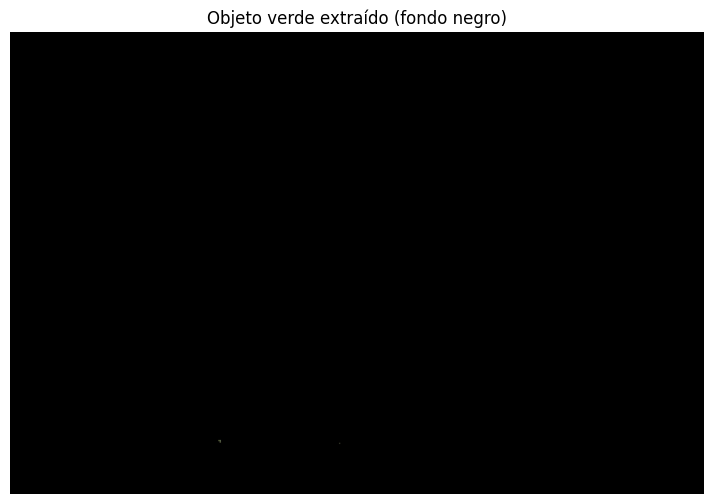

In [5]:
# Aplicar la máscara a la imagen original usando bitwise_and
# Mantiene los píxeles donde la máscara es blanca (255)
# Pone a negro los píxeles donde la máscara es negra (0)
resultado = cv2.bitwise_and(imagen, imagen, mask=mask)

print("✓ Operación bitwise_and aplicada")
print("  Solo se mantienen los píxeles verdes de la imagen original")

# Convertir resultado a RGB para visualización
resultado_rgb = cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(resultado_rgb)
plt.title('Objeto verde extraído (fondo negro)')
plt.axis('off')
plt.show()

## 6. Comparar: original, máscara y resultado final

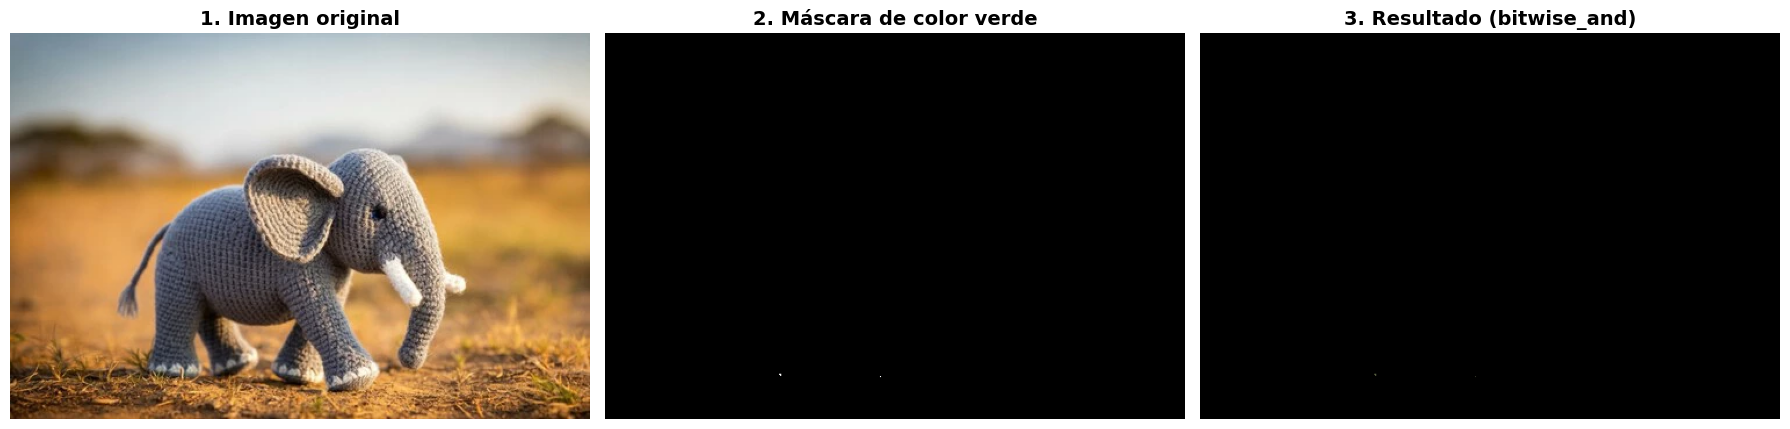


PROCESO DE SEGMENTACIÓN POR COLOR
Color objetivo: VERDE
Espacio de color: HSV
Rango H: 35-85 (matiz del verde)
Rango S: 50-255 (saturación)
Rango V: 50-255 (brillo)

Píxeles verdes detectados: 4
Porcentaje de imagen: 0.00%


In [6]:
# Comparación completa del proceso
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(imagen_rgb)
axes[0].set_title('1. Imagen original', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('2. Máscara de color verde', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(resultado_rgb)
axes[2].set_title('3. Resultado (bitwise_and)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PROCESO DE SEGMENTACIÓN POR COLOR")
print("="*70)
print(f"Color objetivo: VERDE")
print(f"Espacio de color: HSV")
print(f"Rango H: {lower_green[0]}-{upper_green[0]} (matiz del verde)")
print(f"Rango S: {lower_green[1]}-{upper_green[1]} (saturación)")
print(f"Rango V: {lower_green[2]}-{upper_green[2]} (brillo)")
print(f"\nPíxeles verdes detectados: {np.sum(mask == 255)}")
print(f"Porcentaje de imagen: {100 * np.sum(mask == 255) / mask.size:.2f}%")
print("="*70)